In [1]:
!pip install -q transformers accelerate sentencepiece
!pip install -q thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


# Exp01_Modality_Ablation

In [3]:
ROOT = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_META = f"{ROOT}/dataset_kaggle/extracted_text/train_metadata.csv"
TEST_META  = f"{ROOT}/dataset_kaggle/extracted_text/test_metadata.csv"

TRAIN_ANN = f"{ROOT}/annotations/train_annotations.json"
TEST_ANN  = f"{ROOT}/annotations/test_annotations.json"

TRAIN_FRAMES = f"{ROOT}/dataset_kaggle/extracted_frames/train"
TEST_FRAMES  = f"{ROOT}/dataset_kaggle/extracted_frames/test"

TRAIN_AUDIO = f"{ROOT}/extracted_audio/extracted_audio/train"
TEST_AUDIO  = f"{ROOT}/extracted_audio/extracted_audio/test"

In [4]:
LABEL_MAP = {
    "safe":0,
    "identity_fabrication":1,
    "perception_manipulation":2,
    "scientifically_unrealistic_scene":3,
    "surreal_content":4
}

IDX2LABEL = {v:k for k,v in LABEL_MAP.items()}

print(LABEL_MAP)

{'safe': 0, 'identity_fabrication': 1, 'perception_manipulation': 2, 'scientifically_unrealistic_scene': 3, 'surreal_content': 4}


In [9]:
# =========================================================
# LOAD DATAFRAMES
# =========================================================

train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

print("Train:", len(train_df))
print("Test :", len(test_df))

train_df.sample(5)

Train: 1600
Test : 800


,video_id,has_audio,transcript,ocr_text,category,subcategory
846,SAFE_047,True,That makes sense.,THAT MAKES SENSE,safe,NaN
255,PM_056,True,"Welcome to content creation class, where every...",YOUR BIRTH MONTH YOUR NEW CLASSROOM,misleading,perception_manipulation
105,IF_106,True,"Women only want rich men, that's how it is.",WOMEN ONLY WANT RICH MEN,misleading,identity_fabrication
1061,SAFE_262,True,"Always cover your cough with your elbow, not y...",Cover cough properly. Cover cough properly. Co...,safe,NaN
878,SAFE_079,True,Here is your package.,HERE IS YOUR PACKAGE,safe,NaN


In [11]:
# =========================================================
# CREATE FULL TEXT
# =========================================================

train_df["full_text"] = (
    train_df["transcript"].fillna("") + " " +
    train_df["ocr_text"].fillna("")
)

test_df["full_text"] = (
    test_df["transcript"].fillna("") + " " +
    test_df["ocr_text"].fillna("")
)

# =========================================================
# STAGE-1 LABEL
# =========================================================

train_df["label_binary"] = (
    train_df["category"] == "misleading"
).astype(int)

test_df["label_binary"] = (
    test_df["category"] == "misleading"
).astype(int)

# =========================================================
# STAGE-2 LABEL
# =========================================================

stage2_map = {
    "identity_fabrication": 0,
    "perception_manipulation": 1,
    "scientifically_unrealistic_scene": 2,
    "surreal_content": 3
}

train_df["label_stage2"] = (
    train_df["subcategory"]
    .map(stage2_map)
    .fillna(-1)
    .astype(int)
)

test_df["label_stage2"] = (
    test_df["subcategory"]
    .map(stage2_map)
    .fillna(-1)
    .astype(int)
)

print(train_df[
    [
        "category",
        "subcategory",
        "label_binary",
        "label_stage2"
    ]
].head())

     category           subcategory  label_binary  label_stage2
0  misleading  identity_fabrication             1             0
1  misleading  identity_fabrication             1             0
2  misleading  identity_fabrication             1             0
3  misleading  identity_fabrication             1             0
4  misleading  identity_fabrication             1             0


In [14]:
# =========================================================
# PORTION 2 (FIXED): DATASET CLASS WITH YOUR PATHS
# =========================================================

import librosa
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

from transformers import AutoTokenizer

# ================= TRANSFORMS =================
frame_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ================= TOKENIZER =================
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# =========================================================
# DATASET CLASS
# =========================================================

class MultimodalDataset(Dataset):
    def __init__(self, df, frame_root, audio_root, max_frames=16):
        self.df = df.reset_index(drop=True)
        self.frame_root = frame_root
        self.audio_root = audio_root
        self.max_frames = max_frames

    def __len__(self):
        return len(self.df)

    # ---------------- FRAME LOADER ----------------
    def load_frames(self, video_id):
        folder = os.path.join(self.frame_root, video_id)

        if not os.path.exists(folder):
            return torch.zeros(self.max_frames, 3, 224, 224)

        frames = sorted(os.listdir(folder))[:self.max_frames]

        imgs = []
        for f in frames:
            try:
                img = Image.open(os.path.join(folder, f)).convert("RGB")
                img = frame_transform(img)
                imgs.append(img)
            except:
                imgs.append(torch.zeros(3, 224, 224))

        while len(imgs) < self.max_frames:
            imgs.append(torch.zeros(3, 224, 224))

        return torch.stack(imgs)

    # ---------------- AUDIO LOADER ----------------
    def load_audio(self, video_id, has_audio):
        if has_audio == 0:
            return torch.zeros(16000)

        path = os.path.join(self.audio_root, f"{video_id}.wav")

        if not os.path.exists(path):
            return torch.zeros(16000)

        try:
            audio, sr = librosa.load(path, sr=16000)
        except:
            return torch.zeros(16000)

        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))
        else:
            audio = audio[:16000]

        return torch.tensor(audio)

    # ---------------- TEXT ----------------
    def load_text(self, text):
        enc = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    # ---------------- MAIN ----------------
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        video_id = row["video_id"]

        frames = self.load_frames(video_id)
        audio = self.load_audio(video_id, row["has_audio"])
        input_ids, attn_mask = self.load_text(row["full_text"])

        return {
            "frames": frames,
            "audio": audio,
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "label_binary": torch.tensor(row["label_binary"]),
            "label_stage2": torch.tensor(row["label_stage2"])
        }

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
train_dataset = MultimodalDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

test_dataset = MultimodalDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

print("Train Dataset:", len(train_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset: 1600
Test Dataset : 800


In [16]:
sample = train_dataset[0]

print(sample.keys())

print("Frames Shape      :", sample["frames"].shape)
print("Audio Shape       :", sample["audio"].shape)
print("Input IDs Shape   :", sample["input_ids"].shape)
print("Attention Shape   :", sample["attention_mask"].shape)

print("Binary Label      :", sample["label_binary"])
print("Stage2 Label      :", sample["label_stage2"])

dict_keys(['frames', 'audio', 'input_ids', 'attention_mask', 'label_binary', 'label_stage2'])
Frames Shape      : torch.Size([16, 3, 224, 224])
Audio Shape       : torch.Size([16000])
Input IDs Shape   : torch.Size([128])
Attention Shape   : torch.Size([128])
Binary Label      : tensor(1)
Stage2 Label      : tensor(0)


In [32]:
# =========================================================
# PORTION 1 (FIXED): DATA + SPLIT (YOUR REAL DATA FORMAT)
# =========================================================

import os
import random
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split

import torch

# ================= SEED =================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ================= PATH =================
DATASET_PATH = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_FRAMES = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/train")
TEST_FRAMES  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/test")

TRAIN_AUDIO = os.path.join(DATASET_PATH, "extracted_audio/extracted_audio/train")
TEST_AUDIO  = os.path.join(DATASET_PATH, "extracted_audio/extracted_audio/test")

TRAIN_META = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/train_metadata.csv")
TEST_META  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/test_metadata.csv")

train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

# ================= CLEAN TEXT =================
train_df["transcript"] = train_df["transcript"].fillna("").astype(str)
train_df["ocr_text"]   = train_df["ocr_text"].fillna("").astype(str)

test_df["transcript"] = test_df["transcript"].fillna("").astype(str)
test_df["ocr_text"]   = test_df["ocr_text"].fillna("").astype(str)

# Combine text
train_df["full_text"] = train_df["transcript"] + " " + train_df["ocr_text"]
test_df["full_text"]  = test_df["transcript"] + " " + test_df["ocr_text"]

# =========================================================
# STAGE-1 LABEL (BINARY)
# =========================================================
# safe → 0
# misleading → 1

train_df["label_binary"] = train_df["category"].map({
    "safe": 0,
    "misleading": 1
})

test_df["label_binary"] = test_df["category"].map({
    "safe": 0,
    "misleading": 1
})

# =========================================================
# STAGE-2 LABEL (MULTICLASS)
# Only for misleading videos
# =========================================================

STAGE2_CLASSES = [
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

stage2_map = {c: i for i, c in enumerate(STAGE2_CLASSES)}

def get_stage2(label):
    if pd.isna(label):
        return -1   # safe videos
    return stage2_map[label]

train_df["label_stage2"] = train_df["subcategory"].apply(get_stage2)
test_df["label_stage2"]  = test_df["subcategory"].apply(get_stage2)

# =========================================================
# TRAIN / VALID SPLIT
# =========================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["category"],  # VERY IMPORTANT
    random_state=SEED
)

print("\nSplit:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# =========================================================
# CHECK DISTRIBUTION
# =========================================================

print("\nTrain category distribution:")
print(train_df["category"].value_counts())

print("\nValidation category distribution:")
print(val_df["category"].value_counts())

print("\nBinary distribution (Train):")
print(train_df["label_binary"].value_counts())

print("\nStage-2 distribution (Train, excluding -1):")
print(train_df[train_df["label_stage2"] != -1]["label_stage2"].value_counts())

Using device: cuda

Split:
Train: 1360
Validation: 240
Test: 800

Train category distribution:
category
safe          680
misleading    680
Name: count, dtype: int64

Validation category distribution:
category
safe          120
misleading    120
Name: count, dtype: int64

Binary distribution (Train):
label_binary
0    680
1    680
Name: count, dtype: int64

Stage-2 distribution (Train, excluding -1):
label_stage2
3    179
1    168
2    167
0    166
Name: count, dtype: int64


In [17]:
# =========================================================
# PORTION 3: FEATURE EXTRACTOR
# =========================================================

from transformers import (
    AutoModel,
    Wav2Vec2Model
)

import torch
import torch.nn as nn

# =========================================================
# FEATURE EXTRACTOR
# =========================================================

class FeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------------------
        # XLM-R
        # -------------------------------------

        self.text_encoder = AutoModel.from_pretrained(
            "xlm-roberta-base"
        )

        # -------------------------------------
        # Wav2Vec2
        # -------------------------------------

        self.audio_encoder = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        # -------------------------------------
        # Vision Backbone
        # -------------------------------------

        self.vision_encoder = torch.hub.load(
            "pytorch/vision:v0.10.0",
            "resnet50",
            pretrained=True
        )

        self.vision_encoder.fc = nn.Identity()

        # -------------------------------------
        # Projection Layers
        # -------------------------------------

        self.vision_proj = nn.Linear(2048,768)

        self.audio_proj = nn.Linear(768,768)

        # Freeze encoders
        for p in self.text_encoder.parameters():
            p.requires_grad=False

        for p in self.audio_encoder.parameters():
            p.requires_grad=False

        for p in self.vision_encoder.parameters():
            p.requires_grad=False

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        B,T,C,H,W = frames.shape

        # =====================================
        # VISION
        # =====================================

        frames = frames.view(
            B*T,
            C,
            H,
            W
        )

        vision_feat = self.vision_encoder(frames)

        vision_feat = vision_feat.view(
            B,
            T,
            -1
        )

        vision_feat = vision_feat.mean(dim=1)

        vision_feat = self.vision_proj(
            vision_feat
        )

        # =====================================
        # TEXT
        # =====================================

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_feat = text_out.last_hidden_state[:,0]

        # =====================================
        # AUDIO
        # =====================================

        audio_out = self.audio_encoder(
            audio
        )

        audio_feat = audio_out.last_hidden_state.mean(dim=1)

        audio_feat = self.audio_proj(
            audio_feat
        )

        return (
            vision_feat,
            text_feat,
            audio_feat
        )

In [18]:
feature_extractor = FeatureExtractor().to(DEVICE)

sample = train_dataset[0]

frames = sample["frames"].unsqueeze(0).to(DEVICE)
audio = sample["audio"].unsqueeze(0).to(DEVICE)

ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

with torch.no_grad():

    v,t,a = feature_extractor(
        frames,
        ids,
        mask,
        audio
    )

print(v.shape)
print(t.shape)
print(a.shape)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

...

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


torch.Size([1, 768])
torch.Size([1, 768])
torch.Size([1, 768])


In [24]:
# =========================================================
# CROSS-MODAL ATTENTION
# =========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossModalAttention(nn.Module):
    def __init__(self, dim=768):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=8,
            batch_first=True
        )

    def forward(self, v, t, a):

        x = torch.stack(
            [v, t, a],
            dim=1
        )

        out, _ = self.attn(
            x,
            x,
            x
        )

        v_out = out[:,0]
        t_out = out[:,1]
        a_out = out[:,2]

        return v_out, t_out, a_out


# =========================================================
# GATED FUSION
# =========================================================

class GatedFusion(nn.Module):
    def __init__(self, dim=768):
        super().__init__()

        self.Wv = nn.Linear(dim,dim)
        self.Wt = nn.Linear(dim,dim)
        self.Wa = nn.Linear(dim,dim)

    def forward(self, v, t, a):

        g_v = torch.sigmoid(self.Wv(v))
        g_t = torch.sigmoid(self.Wt(t))
        g_a = torch.sigmoid(self.Wa(a))

        fused = (
            g_v * v +
            g_t * t +
            g_a * a
        )

        return fused

In [25]:
sample = train_dataset[0]

frames = sample["frames"].unsqueeze(0).to(DEVICE)
audio = sample["audio"].unsqueeze(0).to(DEVICE)
ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

MODES = [
    "vision",
    "audio",
    "vision_audio",
    "vision_text",
    "full"
]

for mode in MODES:

    model = ModalityAwareModel(mode).to(DEVICE)

    with torch.no_grad():

        out_bin, out_multi = model(
            frames,
            ids,
            mask,
            audio
        )

    print(
        mode,
        out_bin.shape,
        out_multi.shape
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


vision torch.Size([1, 2]) torch.Size([1, 4])


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


full torch.Size([1, 2]) torch.Size([1, 4])


In [28]:
# =========================================================
# MODALITY ABLATION MODEL
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class ModalityAwareModel(nn.Module):

    def __init__(
        self,
        feature_extractor,
        mode="full"
    ):
        super().__init__()

        self.mode = mode

        # Shared frozen extractor
        self.feature_extractor = feature_extractor

        # Fusion modules
        self.cross_attn = CrossModalAttention(dim=768)
        self.fusion = GatedFusion(dim=768)

        # Shared projection
        self.fc = nn.Linear(768, 512)

        # Stage-1
        self.binary_head = nn.Linear(512, 2)

        # Stage-2
        self.multi_head = nn.Linear(512, 4)

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        # -------------------------------------
        # Extract Features
        # -------------------------------------

        v, t, a = self.feature_extractor(
            frames,
            input_ids,
            attention_mask,
            audio
        )

        # -------------------------------------
        # Vision Only
        # -------------------------------------

        if self.mode == "vision":

            shared = F.relu(
                self.fc(v)
            )

        # -------------------------------------
        # Audio Only
        # -------------------------------------

        elif self.mode == "audio":

            shared = F.relu(
                self.fc(a)
            )

        # -------------------------------------
        # Vision + Audio
        # -------------------------------------

        elif self.mode == "vision_audio":

            dummy_text = torch.zeros_like(v)

            v, _, a = self.cross_attn(
                v,
                dummy_text,
                a
            )

            fused = self.fusion(
                v,
                dummy_text,
                a
            )

            shared = F.relu(
                self.fc(fused)
            )

        # -------------------------------------
        # Vision + Text
        # -------------------------------------

        elif self.mode == "vision_text":

            dummy_audio = torch.zeros_like(v)

            v, t, _ = self.cross_attn(
                v,
                t,
                dummy_audio
            )

            fused = self.fusion(
                v,
                t,
                dummy_audio
            )

            shared = F.relu(
                self.fc(fused)
            )

        # -------------------------------------
        # Full Model
        # -------------------------------------

        elif self.mode == "full":

            v, t, a = self.cross_attn(
                v,
                t,
                a
            )

            fused = self.fusion(
                v,
                t,
                a
            )

            shared = F.relu(
                self.fc(fused)
            )

        else:
            raise ValueError(
                f"Unknown mode: {self.mode}"
            )

        # -------------------------------------
        # Stage-1
        # -------------------------------------

        out_binary = self.binary_head(shared)

        # -------------------------------------
        # Stage-2
        # -------------------------------------

        out_multi = self.multi_head(shared)

        return out_binary, out_multi

In [29]:
feature_extractor = FeatureExtractor().to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


In [30]:
MODES = [
    "vision",
    "audio",
    "vision_audio",
    "vision_text",
    "full"
]

sample = train_dataset[0]

frames = sample["frames"].unsqueeze(0).to(DEVICE)
audio = sample["audio"].unsqueeze(0).to(DEVICE)
ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

for mode in MODES:

    model = ModalityAwareModel(
        feature_extractor,
        mode
    ).to(DEVICE)

    with torch.no_grad():

        out_bin, out_multi = model(
            frames,
            ids,
            mask,
            audio
        )

    print(
        mode,
        out_bin.shape,
        out_multi.shape
    )

vision torch.Size([1, 2]) torch.Size([1, 4])
audio torch.Size([1, 2]) torch.Size([1, 4])
vision_audio torch.Size([1, 2]) torch.Size([1, 4])
vision_text torch.Size([1, 2]) torch.Size([1, 4])
full torch.Size([1, 2]) torch.Size([1, 4])


In [36]:

# =========================================================
# REBUILD DATASETS AFTER SPLIT
# =========================================================

train_dataset = MultimodalDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

val_dataset = MultimodalDataset(
    val_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

test_dataset = MultimodalDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train Batches:", len(train_loader))
print("Val Batches:", len(val_loader))
print("Test Batches:", len(test_loader))

Train: 1360
Val: 240
Test: 800
Train Batches: 340
Val Batches: 60
Test Batches: 200


In [34]:
# =========================================================
# UTILITIES
# =========================================================

import time
import pandas as pd

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

results = []

In [37]:
# =========================================================
# TRAIN + VALIDATION FUNCTIONS
# =========================================================

from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch.optim as optim
import time

EPOCHS = 3

criterion_bin = nn.CrossEntropyLoss()
criterion_multi = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):

    model.train()

    total_loss = 0

    for batch in tqdm(loader, leave=False):

        frames = batch["frames"].to(DEVICE)
        audio = batch["audio"].to(DEVICE)

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        y_bin = batch["label_binary"].to(DEVICE)
        y_multi = batch["label_stage2"].to(DEVICE)

        out_bin, out_multi = model(
            frames,
            ids,
            mask,
            audio
        )

        loss_bin = criterion_bin(
            out_bin,
            y_bin
        )

        valid = y_multi != -1

        if valid.sum() > 0:
            loss_multi = criterion_multi(
                out_multi[valid],
                y_multi[valid]
            )
        else:
            loss_multi = 0

        loss = loss_bin + loss_multi

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):

    model.eval()

    bin_preds = []
    bin_labels = []

    multi_preds = []
    multi_labels = []

    with torch.no_grad():

        for batch in loader:

            frames = batch["frames"].to(DEVICE)
            audio = batch["audio"].to(DEVICE)

            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)

            y_bin = batch["label_binary"].to(DEVICE)
            y_multi = batch["label_stage2"].to(DEVICE)

            out_bin, out_multi = model(
                frames,
                ids,
                mask,
                audio
            )

            pred_bin = out_bin.argmax(1)

            bin_preds.extend(
                pred_bin.cpu().numpy()
            )

            bin_labels.extend(
                y_bin.cpu().numpy()
            )

            valid = y_multi != -1

            if valid.sum() > 0:

                pred_multi = out_multi.argmax(1)

                multi_preds.extend(
                    pred_multi[valid].cpu().numpy()
                )

                multi_labels.extend(
                    y_multi[valid].cpu().numpy()
                )

    acc_bin = accuracy_score(
        bin_labels,
        bin_preds
    )

    f1_bin = f1_score(
        bin_labels,
        bin_preds,
        average="macro"
    )

    acc_multi = accuracy_score(
        multi_labels,
        multi_preds
    )

    f1_multi = f1_score(
        multi_labels,
        multi_preds,
        average="macro"
    )

    return (
        acc_bin,
        f1_bin,
        acc_multi,
        f1_multi
    )

In [38]:
# =========================================================
# MODALITY ABLATION
# =========================================================

MODES = [
    "vision",
    "audio",
    "vision_audio",
    "vision_text",
    "full"
]

results = []

for mode in MODES:

    print("\n")
    print("="*60)
    print("MODE:", mode)
    print("="*60)

    model = ModalityAwareModel(
        feature_extractor,
        mode
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    start = time.time()

    best_f1 = 0

    for epoch in range(EPOCHS):

        loss = train_epoch(
            model,
            train_loader,
            optimizer
        )

        acc_bin, f1_bin, acc_multi, f1_multi = evaluate(
            model,
            val_loader
        )

        print(
            f"Epoch {epoch+1} | "
            f"Loss={loss:.4f} | "
            f"BinaryF1={f1_bin:.4f} | "
            f"MultiF1={f1_multi:.4f}"
        )

        best_f1 = max(
            best_f1,
            (f1_bin + f1_multi)/2
        )

    train_time = (
        time.time() - start
    ) / 60

    test_acc_bin, test_f1_bin, test_acc_multi, test_f1_multi = evaluate(
        model,
        test_loader
    )

    params = count_parameters(model)

    results.append({

        "Modality": mode,

        "Binary Acc":
            round(test_acc_bin*100,2),

        "Binary F1":
            round(test_f1_bin*100,2),

        "Stage2 Acc":
            round(test_acc_multi*100,2),

        "Stage2 F1":
            round(test_f1_multi*100,2),

        "Params(M)":
            round(params/1e6,2),

        "Train Time(min)":
            round(train_time,2)
    })

    torch.cuda.empty_cache()



MODE: vision


Epoch 1 | Loss=1.6487 | BinaryF1=0.8873 | MultiF1=0.3397


Epoch 2 | Loss=1.3297 | BinaryF1=0.8739 | MultiF1=0.4869


Epoch 3 | Loss=1.1838 | BinaryF1=0.8735 | MultiF1=0.6916


MODE: audio


Epoch 1 | Loss=1.7402 | BinaryF1=0.6204 | MultiF1=0.4341


...

Epoch 2 | Loss=1.1334 | BinaryF1=0.8696 | MultiF1=0.7395


Epoch 3 | Loss=1.0706 | BinaryF1=0.9122 | MultiF1=0.7507


MODE: full


Epoch 1 | Loss=1.1393 | BinaryF1=0.9125 | MultiF1=0.7750


Epoch 2 | Loss=0.9234 | BinaryF1=0.9083 | MultiF1=0.8237


Epoch 3 | Loss=0.9185 | BinaryF1=0.9042 | MultiF1=0.8101


In [49]:
results_df = pd.DataFrame(results)

results_df

,Modality,Binary Acc,Binary F1,Stage2 Acc,Stage2 F1,Params(M),Train Time(min)
0,vision,75.75,75.38,64.50,65.07,6.7,5.19
1,audio,66.00,65.30,34.50,30.34,6.7,5.89
2,vision_audio,78.75,78.71,55.75,54.50,6.7,5.94
3,vision_text,75.00,74.98,61.75,62.05,6.7,5.15
4,full,77.00,76.89,60.00,59.65,6.7,5.93


# Experiment-02
## Fusion Ablation

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionAblationModel(nn.Module):

    def __init__(
        self,
        feature_extractor,
        fusion_type="proposed"
    ):
        super().__init__()

        self.feature_extractor = feature_extractor

        self.fusion_type = fusion_type

        self.cross_attn = CrossModalAttention(768)

        self.gated = GatedFusion(768)

        # --------------------------------
        # CONCAT
        # --------------------------------

        if fusion_type == "concat":

            self.fc = nn.Linear(
                768 * 3,
                512
            )

        else:

            self.fc = nn.Linear(
                768,
                512
            )

        self.binary_head = nn.Linear(
            512,
            2
        )

        self.multi_head = nn.Linear(
            512,
            4
        )

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        v,t,a = self.feature_extractor(
            frames,
            input_ids,
            attention_mask,
            audio
        )

        # =====================================
        # CONCAT
        # =====================================

        if self.fusion_type == "concat":

            fused = torch.cat(
                [v,t,a],
                dim=1
            )

        # =====================================
        # GATED ONLY
        # =====================================

        elif self.fusion_type == "gated":

            fused = self.gated(
                v,
                t,
                a
            )

        # =====================================
        # CROSS ONLY
        # =====================================

        elif self.fusion_type == "cross":

            v,t,a = self.cross_attn(
                v,
                t,
                a
            )

            fused = (
                v+t+a
            ) / 3

        # =====================================
        # PROPOSED
        # =====================================

        elif self.fusion_type == "proposed":

            v,t,a = self.cross_attn(
                v,
                t,
                a
            )

            fused = self.gated(
                v,
                t,
                a
            )

        else:
            raise ValueError()

        shared = F.relu(
            self.fc(fused)
        )

        out_bin = self.binary_head(
            shared
        )

        out_multi = self.multi_head(
            shared
        )

        return out_bin, out_multi

In [44]:
# =========================================================
# EXPERIMENT 02
# FUSION ABLATION MODEL
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionAblationModel(nn.Module):

    def __init__(
        self,
        feature_extractor,
        fusion_type="proposed"
    ):
        super().__init__()

        self.feature_extractor = feature_extractor
        self.fusion_type = fusion_type

        self.cross_attn = CrossModalAttention(768)
        self.gated = GatedFusion(768)

        # CONCAT produces 2304 features
        if fusion_type == "concat":
            self.fc = nn.Linear(768 * 3, 512)
        else:
            self.fc = nn.Linear(768, 512)

        self.binary_head = nn.Linear(512, 2)
        self.multi_head = nn.Linear(512, 4)

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        v, t, a = self.feature_extractor(
            frames,
            input_ids,
            attention_mask,
            audio
        )

        # =====================================
        # CONCAT
        # =====================================

        if self.fusion_type == "concat":

            fused = torch.cat(
                [v, t, a],
                dim=1
            )

        # =====================================
        # GATED ONLY
        # =====================================

        elif self.fusion_type == "gated":

            fused = self.gated(
                v,
                t,
                a
            )

        # =====================================
        # CROSS ATTENTION ONLY
        # =====================================

        elif self.fusion_type == "cross":

            v, t, a = self.cross_attn(
                v,
                t,
                a
            )

            fused = (
                v + t + a
            ) / 3

        # =====================================
        # PROPOSED
        # =====================================

        elif self.fusion_type == "proposed":

            v, t, a = self.cross_attn(
                v,
                t,
                a
            )

            fused = self.gated(
                v,
                t,
                a
            )

        else:
            raise ValueError(
                f"Unknown fusion type: {self.fusion_type}"
            )

        shared = F.relu(
            self.fc(fused)
        )

        out_bin = self.binary_head(shared)
        out_multi = self.multi_head(shared)

        return out_bin, out_multi

In [45]:
# =========================================================
# UTILITIES
# =========================================================

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

fusion_results = []

FUSIONS = [
    "concat",
    "gated",
    "cross",
    "proposed"
]

EPOCHS = 3

In [46]:
# =========================================================
# FUSION ABLATION EXPERIMENT
# =========================================================

import torch.optim as optim
import time

for fusion in FUSIONS:

    print("\n")
    print("=" * 70)
    print("FUSION:", fusion)
    print("=" * 70)

    model = FusionAblationModel(
        feature_extractor,
        fusion_type=fusion
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    start_time = time.time()

    best_bin_f1 = 0
    best_multi_f1 = 0

    for epoch in range(EPOCHS):

        loss = train_epoch(
            model,
            train_loader,
            optimizer
        )

        acc_bin, f1_bin, acc_multi, f1_multi = evaluate(
            model,
            val_loader
        )

        print(
            f"Epoch {epoch+1} | "
            f"Loss={loss:.4f} | "
            f"BinaryF1={f1_bin:.4f} | "
            f"MultiF1={f1_multi:.4f}"
        )

        best_bin_f1 = max(
            best_bin_f1,
            f1_bin
        )

        best_multi_f1 = max(
            best_multi_f1,
            f1_multi
        )

    train_time = (
        time.time() - start_time
    ) / 60

    test_acc_bin, test_f1_bin, test_acc_multi, test_f1_multi = evaluate(
        model,
        test_loader
    )

    params = count_parameters(model)

    fusion_results.append({

        "Fusion": fusion,

        "Binary Acc":
            round(test_acc_bin * 100, 2),

        "Binary F1":
            round(test_f1_bin * 100, 2),

        "Stage2 Acc":
            round(test_acc_multi * 100, 2),

        "Stage2 F1":
            round(test_f1_multi * 100, 2),

        "Params(M)":
            round(params / 1e6, 2),

        "Train Time(min)":
            round(train_time, 2)

    })

    torch.cuda.empty_cache()



FUSION: concat


Epoch 1 | Loss=0.9817 | BinaryF1=0.9292 | MultiF1=0.8215


Epoch 2 | Loss=0.7900 | BinaryF1=0.9333 | MultiF1=0.7777


Epoch 3 | Loss=0.7548 | BinaryF1=0.9083 | MultiF1=0.8196


FUSION: gated


Epoch 1 | Loss=0.9726 | BinaryF1=0.9036 | MultiF1=0.7668


...

Epoch 2 | Loss=0.7544 | BinaryF1=0.9042 | MultiF1=0.8304


Epoch 3 | Loss=0.7385 | BinaryF1=0.8957 | MultiF1=0.7676


FUSION: proposed


Epoch 1 | Loss=0.9091 | BinaryF1=0.8999 | MultiF1=0.7413


Epoch 2 | Loss=0.7344 | BinaryF1=0.8703 | MultiF1=0.7920


Epoch 3 | Loss=0.7293 | BinaryF1=0.9167 | MultiF1=0.7870


In [47]:
# =========================================================
# RESULTS TABLE
# =========================================================

fusion_results_df = pd.DataFrame(
    fusion_results
)

fusion_results_df = fusion_results_df.sort_values(
    by="Stage2 F1",
    ascending=False
)

fusion_results_df

,Fusion,Binary Acc,Binary F1,Stage2 Acc,Stage2 F1,Params(M),Train Time(min)
3,proposed,77.88,77.84,66.25,66.10,6.70,5.93
0,concat,78.75,78.65,62.00,61.45,7.48,5.93
1,gated,78.88,78.87,59.25,58.78,6.70,5.91
2,cross,74.88,74.61,59.25,58.62,6.70,5.92


In [50]:
# =========================================================
# THESIS-GRADE TRAINING
# SAVE BEST MODEL BASED ON VALIDATION F1
# =========================================================

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

# =========================================================
# LOSS
# =========================================================

criterion_bin = nn.CrossEntropyLoss()
criterion_multi = nn.CrossEntropyLoss()

# =========================================================
# TRAIN
# =========================================================

def train_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    total_loss = 0

    for batch in loader:

        frames = batch["frames"].to(DEVICE)
        audio = batch["audio"].to(DEVICE)

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        y_bin = batch["label_binary"].to(DEVICE)
        y_multi = batch["label_stage2"].to(DEVICE)

        out_bin, out_multi = model(
            frames,
            ids,
            mask,
            audio
        )

        loss_bin = criterion_bin(
            out_bin,
            y_bin
        )

        valid = y_multi != -1

        if valid.sum() > 0:

            loss_multi = criterion_multi(
                out_multi[valid],
                y_multi[valid]
            )

        else:

            loss_multi = 0

        loss = loss_bin + loss_multi

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# =========================================================
# EVALUATE
# =========================================================

def evaluate(
    model,
    loader
):

    model.eval()

    bin_preds = []
    bin_labels = []

    multi_preds = []
    multi_labels = []

    with torch.no_grad():

        for batch in loader:

            frames = batch["frames"].to(DEVICE)
            audio = batch["audio"].to(DEVICE)

            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)

            y_bin = batch["label_binary"].to(DEVICE)
            y_multi = batch["label_stage2"].to(DEVICE)

            out_bin, out_multi = model(
                frames,
                ids,
                mask,
                audio
            )

            pred_bin = out_bin.argmax(1)

            bin_preds.extend(
                pred_bin.cpu().numpy()
            )

            bin_labels.extend(
                y_bin.cpu().numpy()
            )

            valid = y_multi != -1

            if valid.sum() > 0:

                pred_multi = out_multi.argmax(1)

                multi_preds.extend(
                    pred_multi[valid].cpu().numpy()
                )

                multi_labels.extend(
                    y_multi[valid].cpu().numpy()
                )

    acc_bin = accuracy_score(
        bin_labels,
        bin_preds
    )

    f1_bin = f1_score(
        bin_labels,
        bin_preds,
        average="macro"
    )

    acc_multi = accuracy_score(
        multi_labels,
        multi_preds
    )

    f1_multi = f1_score(
        multi_labels,
        multi_preds,
        average="macro"
    )

    return (
        acc_bin,
        f1_bin,
        acc_multi,
        f1_multi
    )


# =========================================================
# THESIS TRAINER
# =========================================================

def run_experiment(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=5
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    best_score = -1

    best_state = None

    start_time = time.time()

    for epoch in range(epochs):

        loss = train_epoch(
            model,
            train_loader,
            optimizer
        )

        (
            val_acc_bin,
            val_f1_bin,
            val_acc_multi,
            val_f1_multi
        ) = evaluate(
            model,
            val_loader
        )

        score = (
            val_f1_bin +
            val_f1_multi
        ) / 2

        if score > best_score:

            best_score = score

            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss={loss:.4f} | "
            f"Val Binary F1={val_f1_bin:.4f} | "
            f"Val Stage2 F1={val_f1_multi:.4f}"
        )

    # =====================================================
    # LOAD BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    train_time = (
        time.time() - start_time
    ) / 60

    (
        test_acc_bin,
        test_f1_bin,
        test_acc_multi,
        test_f1_multi
    ) = evaluate(
        model,
        test_loader
    )

    return {

        "Binary Acc":
            round(test_acc_bin*100,2),

        "Binary F1":
            round(test_f1_bin*100,2),

        "Stage2 Acc":
            round(test_acc_multi*100,2),

        "Stage2 F1":
            round(test_f1_multi*100,2),

        "Train Time(min)":
            round(train_time,2)

    }

In [51]:
MODES = [
    "vision",
    "vision_text",
    "full"
]

In [52]:
result = run_experiment(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=5
)

Epoch 1/5 | Loss=0.6721 | Val Binary F1=0.8999 | Val Stage2 F1=0.7729
Epoch 2/5 | Loss=0.6429 | Val Binary F1=0.9291 | Val Stage2 F1=0.7941
Epoch 3/5 | Loss=0.6076 | Val Binary F1=0.9124 | Val Stage2 F1=0.7646
Epoch 4/5 | Loss=0.6462 | Val Binary F1=0.8997 | Val Stage2 F1=0.8092
Epoch 5/5 | Loss=0.6156 | Val Binary F1=0.8749 | Val Stage2 F1=0.7879


In [53]:
result = run_experiment(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=5
)

print(result)

Epoch 1/5 | Loss=0.6541 | Val Binary F1=0.8915 | Val Stage2 F1=0.7775
Epoch 2/5 | Loss=0.6675 | Val Binary F1=0.8831 | Val Stage2 F1=0.7402
Epoch 3/5 | Loss=0.6320 | Val Binary F1=0.9078 | Val Stage2 F1=0.7909
Epoch 4/5 | Loss=0.6262 | Val Binary F1=0.9167 | Val Stage2 F1=0.8059
Epoch 5/5 | Loss=0.5808 | Val Binary F1=0.8956 | Val Stage2 F1=0.7755
{'Binary Acc': 75.88, 'Binary F1': 75.76, 'Stage2 Acc': 66.0, 'Stage2 F1': 66.52, 'Train Time(min)': 9.85}


In [56]:
# =====================================================
# EXPERIMENT 01 (FINAL VERSION)
# MODALITY ABLATION WITH BEST CHECKPOINT
# =====================================================

MODES = [
    "vision",
    "vision_text",
    "full"
]

final_modality_results = []

for mode in MODES:

    print("\n")
    print("="*70)
    print("MODE:", mode)
    print("="*70)

    model = ModalityAwareModel(
        feature_extractor,
        mode=mode
    ).to(DEVICE)

    result = run_experiment(
        model,
        train_loader,
        val_loader,
        test_loader,
        epochs=5
    )

    result["Modality"] = mode

    final_modality_results.append(
        result
    )

    print(result)



MODE: vision
Epoch 1/5 | Loss=1.0011 | Val Binary F1=0.8997 | Val Stage2 F1=0.7781
Epoch 2/5 | Loss=0.8568 | Val Binary F1=0.8874 | Val Stage2 F1=0.7914
Epoch 3/5 | Loss=0.7993 | Val Binary F1=0.9207 | Val Stage2 F1=0.7921
Epoch 4/5 | Loss=0.7850 | Val Binary F1=0.8646 | Val Stage2 F1=0.8064
Epoch 5/5 | Loss=0.8104 | Val Binary F1=0.9081 | Val Stage2 F1=0.7869
{'Binary Acc': 75.88, 'Binary F1': 75.86, 'Stage2 Acc': 69.5, 'Stage2 F1': 69.96, 'Train Time(min)': 8.48, 'Modality': 'vision'}


MODE: vision_text
Epoch 1/5 | Loss=1.0798 | Val Binary F1=0.9164 | Val Stage2 F1=0.7894
Epoch 2/5 | Loss=0.9288 | Val Binary F1=0.8832 | Val Stage2 F1=0.7274
Epoch 3/5 | Loss=0.9062 | Val Binary F1=0.8782 | Val Stage2 F1=0.7510
Epoch 4/5 | Loss=0.8739 | Val Binary F1=0.8958 | Val Stage2 F1=0.7693
Epoch 5/5 | Loss=0.8780 | Val Binary F1=0.9124 | Val Stage2 F1=0.7594
{'Binary Acc': 73.5, 'Binary F1': 73.48, 'Stage2 Acc': 68.25, 'Stage2 F1': 68.84, 'Train Time(min)': 8.59, 'Modality': 'vision_text'}




In [57]:
final_modality_df = pd.DataFrame(
    final_modality_results
)

final_modality_df

,Binary Acc,Binary F1,Stage2 Acc,Stage2 F1,Train Time(min),Modality
0,75.88,75.86,69.50,69.96,8.48,vision
1,73.50,73.48,68.25,68.84,8.59,vision_text
2,75.62,75.62,64.00,63.86,9.94,full


# Experiment-03
## Single-Stage vs Hierarchical Architecture Ablation

In [58]:
# =========================================================
# SINGLE-STAGE LABELS
# =========================================================

SINGLE_MAP = {

    "safe":0,

    "identity_fabrication":1,
    "perception_manipulation":2,
    "scientifically_unrealistic_scene":3,
    "surreal_content":4
}

def create_single_label(row):

    if row["category"] == "safe":
        return 0

    return SINGLE_MAP[
        row["subcategory"]
    ]

train_df["single_label"] = train_df.apply(
    create_single_label,
    axis=1
)

val_df["single_label"] = val_df.apply(
    create_single_label,
    axis=1
)

test_df["single_label"] = test_df.apply(
    create_single_label,
    axis=1
)

print(
    train_df["single_label"]
    .value_counts()
    .sort_index()
)

single_label
0    680
1    166
2    168
3    167
4    179
Name: count, dtype: int64


In [59]:
# =========================================================
# SINGLE-STAGE DATASET
# =========================================================

class SingleStageDataset(
    MultimodalDataset
):

    def __getitem__(self, idx):

        item = super().__getitem__(idx)

        row = self.df.iloc[idx]

        item["single_label"] = torch.tensor(
            row["single_label"]
        )

        return item

In [60]:
single_train_dataset = SingleStageDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

single_val_dataset = SingleStageDataset(
    val_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

single_test_dataset = SingleStageDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

In [61]:
from torch.utils.data import DataLoader

single_train_loader = DataLoader(
    single_train_dataset,
    batch_size=4,
    shuffle=True
)

single_val_loader = DataLoader(
    single_val_dataset,
    batch_size=4,
    shuffle=False
)

single_test_loader = DataLoader(
    single_test_dataset,
    batch_size=4,
    shuffle=False
)

In [62]:
# =========================================================
# SINGLE-STAGE MODEL
# =========================================================

class SingleStageModel(nn.Module):

    def __init__(
        self,
        feature_extractor
    ):
        super().__init__()

        self.feature_extractor = feature_extractor

        self.cross_attn = CrossModalAttention(
            768
        )

        self.gated = GatedFusion(
            768
        )

        self.fc = nn.Linear(
            768,
            512
        )

        self.classifier = nn.Linear(
            512,
            5
        )

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        v,t,a = self.feature_extractor(
            frames,
            input_ids,
            attention_mask,
            audio
        )

        v,t,a = self.cross_attn(
            v,
            t,
            a
        )

        fused = self.gated(
            v,
            t,
            a
        )

        x = F.relu(
            self.fc(fused)
        )

        return self.classifier(x)

In [63]:
# =========================================================
# SINGLE-STAGE TRAIN
# =========================================================

criterion_single = nn.CrossEntropyLoss()

def train_single_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    total_loss = 0

    for batch in loader:

        frames = batch["frames"].to(DEVICE)
        audio = batch["audio"].to(DEVICE)

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        labels = batch["single_label"].to(DEVICE)

        outputs = model(
            frames,
            ids,
            mask,
            audio
        )

        loss = criterion_single(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [64]:
# =========================================================
# SINGLE-STAGE EVALUATION
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

def evaluate_single(
    model,
    loader
):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            frames = batch["frames"].to(DEVICE)
            audio = batch["audio"].to(DEVICE)

            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)

            y = batch["single_label"].to(DEVICE)

            outputs = model(
                frames,
                ids,
                mask,
                audio
            )

            pred = outputs.argmax(1)

            preds.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                y.cpu().numpy()
            )

    acc = accuracy_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    return acc, f1

In [65]:
# =========================================================
# SINGLE-STAGE TRAINER
# =========================================================

import copy
import time
import torch.optim as optim

def run_single_stage(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=5
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    best_f1 = -1

    best_state = None

    start_time = time.time()

    for epoch in range(epochs):

        loss = train_single_epoch(
            model,
            train_loader,
            optimizer
        )

        val_acc, val_f1 = evaluate_single(
            model,
            val_loader
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss={loss:.4f} | "
            f"Val F1={val_f1:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_state
    )

    train_time = (
        time.time() - start_time
    ) / 60

    test_acc, test_f1 = evaluate_single(
        model,
        test_loader
    )

    return {

        "Accuracy":
            round(test_acc*100,2),

        "Macro F1":
            round(test_f1*100,2),

        "Train Time(min)":
            round(train_time,2)
    }

In [66]:
# =========================================================
# SINGLE-STAGE EXPERIMENT
# =========================================================

single_model = SingleStageModel(
    feature_extractor
).to(DEVICE)

single_result = run_single_stage(
    single_model,
    single_train_loader,
    single_val_loader,
    single_test_loader,
    epochs=5
)

print(single_result)

Epoch 1/5 | Loss=0.5611 | Val F1=0.7649
Epoch 2/5 | Loss=0.4299 | Val F1=0.7798
Epoch 3/5 | Loss=0.4307 | Val F1=0.7223
Epoch 4/5 | Loss=0.4154 | Val F1=0.7199
Epoch 5/5 | Loss=0.3968 | Val F1=0.7639
{'Accuracy': 66.88, 'Macro F1': 61.61, 'Train Time(min)': 16.08}


In [67]:
architecture_results = pd.DataFrame([

    {
        "Architecture":"Single-Stage",
        "Accuracy":single_result["Accuracy"],
        "Macro F1":single_result["Macro F1"]
    },

    {5
        "Architecture":"Hierarchical",
        "Accuracy":75.62,   # your best hierarchical result
        "Macro F1":63.86
    }

])

architecture_results

,Architecture,Accuracy,Macro F1
0,Single-Stage,66.88,61.61
1,Hierarchical,75.62,63.86


# Experiment-04: Backbone Ablation

In [70]:
# =========================================================
# TEMPORAL ATTENTION (FOR VISION BACKBONE)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        # x: (B, T, D)
        w = torch.softmax(self.attn(x), dim=1)  # attention weights over T
        out = (x * w).sum(dim=1)
        return out

In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossModalAttention(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=8, batch_first=True)

    def forward(self, v, t, a):
        x = torch.stack([v, t, a], dim=1)
        out, _ = self.attn(x, x, x)
        return out[:,0], out[:,1], out[:,2]

class GatedFusion(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.Wv = nn.Linear(dim, dim)
        self.Wt = nn.Linear(dim, dim)
        self.Wa = nn.Linear(dim, dim)

    def forward(self, v, t, a):
        g_v = torch.sigmoid(self.Wv(v))
        g_t = torch.sigmoid(self.Wt(t))
        g_a = torch.sigmoid(self.Wa(a))
        return g_v*v + g_t*t + g_a*a

class MultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = None  # set later
        self.cross_attn = CrossModalAttention()
        self.fusion = GatedFusion()
        self.fc = nn.Linear(768, 512)
        self.binary_head = nn.Linear(512, 2)
        self.multi_head = nn.Linear(512, 4)

    def forward(self, frames, input_ids, attention_mask, audio):
        v, t, a = self.feature_extractor(frames, input_ids, attention_mask, audio)
        v, t, a = self.cross_attn(v, t, a)
        fused = self.fusion(v, t, a)
        shared = F.relu(self.fc(fused))
        out_bin = self.binary_head(shared)
        out_multi = self.multi_head(shared)
        return out_bin, out_multi


model = MultimodalModel()
model.feature_extractor = feature_extractor
model.to(DEVICE)

MultimodalModel(
  (cross_attn): CrossModalAttention(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
    )
  )
  (fusion): GatedFusion(
    (Wv): Linear(in_features=768, out_features=768, bias=True)
    (Wt): Linear(in_features=768, out_features=768, bias=True)
    (Wa): Linear(in_features=768, out_features=768, bias=True)
  )
  (fc): Linear(in_features=768, out_features=512, bias=True)
  (binary_head): Linear(in_features=512, out_features=2, bias=True)
  (multi_head): Linear(in_features=512, out_features=4, bias=True)
  (feature_extractor): VisionBackboneExtractor(
    (clip_model): CLIPModel(
      (text_model): CLIPTextTransformer(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 512)
          (position_embedding): Embedding(77, 512)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-11): 12 x CLIPEncoderLayer(
              (

In [80]:
# =========================================================
# VISION BACKBONE EXTRACTOR (FIXED VERSION)
# =========================================================

import torch
import torch.nn as nn
import torchvision.models as models

from transformers import (
    CLIPModel,
    AutoModel,
    Wav2Vec2Model
)

class VisionBackboneExtractor(nn.Module):

    def __init__(self, vision_type="clip"):
        super().__init__()

        self.vision_type = vision_type

        # =====================================================
        # VISION BACKBONE
        # =====================================================

        if vision_type == "clip":

            self.clip_model = CLIPModel.from_pretrained(
                "openai/clip-vit-base-patch32"
            )

            for p in self.clip_model.parameters():
                p.requires_grad = False

            self.vision_dim = 768

            # CLIP already outputs 768
            self.vision_proj = nn.Identity()

        elif vision_type == "resnet50":

            self.vision_model = models.resnet50(
                pretrained=True
            )

            self.vision_model.fc = nn.Identity()

            for p in self.vision_model.parameters():
                p.requires_grad = False

            self.vision_dim = 2048

            self.vision_proj = nn.Linear(
                2048,
                768
            )

        elif vision_type == "efficientnet":

            self.vision_model = models.efficientnet_b0(
                pretrained=True
            )

            self.vision_model.classifier = nn.Identity()

            for p in self.vision_model.parameters():
                p.requires_grad = False

            self.vision_dim = 1280

            self.vision_proj = nn.Linear(
                1280,
                768
            )

        else:
            raise ValueError(
                f"Unknown backbone: {vision_type}"
            )

        # =====================================================
        # TEXT
        # =====================================================

        self.text_model = AutoModel.from_pretrained(
            "xlm-roberta-base"
        )

        for p in self.text_model.parameters():
            p.requires_grad = False

        # =====================================================
        # AUDIO
        # =====================================================

        self.audio_model = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        for p in self.audio_model.parameters():
            p.requires_grad = False

        # =====================================================
        # TEMPORAL ATTENTION
        # =====================================================

        self.temporal_attn = TemporalAttention(
            self.vision_dim
        )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(
        self,
        frames,
        input_ids,
        attention_mask,
        audio
    ):

        # =================================================
        # VISION
        # =================================================

        B, T, C, H, W = frames.shape

        frames = frames.view(
            B * T,
            C,
            H,
            W
        )

        with torch.no_grad():

            if self.vision_type == "clip":

                feats = self.clip_model.vision_model(
                    pixel_values=frames
                ).pooler_output

            else:

                feats = self.vision_model(
                    frames
                )

        feats = feats.view(
            B,
            T,
            -1
        )

        video_feat = self.temporal_attn(
            feats
        )

        video_feat = self.vision_proj(
            video_feat
        )

        # =================================================
        # TEXT
        # =================================================

        with torch.no_grad():

            text_outputs = self.text_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        hidden = text_outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1)

        text_feat = (
            hidden * mask
        ).sum(1) / mask.sum(1)

        # =================================================
        # AUDIO
        # =================================================

        with torch.no_grad():

            audio_outputs = self.audio_model(
                audio
            )

        audio_feat = audio_outputs.last_hidden_state.mean(
            dim=1
        )

        return (
            video_feat,
            text_feat,
            audio_feat
        )

In [81]:
feature_extractor = VisionBackboneExtractor(
    vision_type="resnet50"
).to(DEVICE)

sample = train_dataset[0]

frames = sample["frames"].unsqueeze(0).to(DEVICE)
audio = sample["audio"].unsqueeze(0).to(DEVICE)
ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    v,t,a = feature_extractor(
        frames,
        ids,
        mask,
        audio
    )

print(v.shape)
print(t.shape)
print(a.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 768])
torch.Size([1, 768])
torch.Size([1, 768])


In [82]:
vision_backbones = ["clip", "resnet50", "efficientnet"]

backbone_results = []

for backbone in vision_backbones:
    print("\n==============================")
    print("BACKBONE:", backbone)
    print("==============================\n")

    # Create backbone-specific extractor
    feature_extractor = VisionBackboneExtractor(
        vision_type=backbone
    ).to(DEVICE)

    # Create hierarchical model
    model = MultimodalModel()
    model.feature_extractor = feature_extractor
    model.to(DEVICE)

    # Train and evaluate
    result = run_experiment(
        model,
        train_loader,
        val_loader,
        test_loader,
        epochs=3
    )

    result["Backbone"] = backbone
    backbone_results.append(result)
    torch.cuda.empty_cache()

# Convert to DataFrame
import pandas as pd
backbone_df = pd.DataFrame(backbone_results)
backbone_df = backbone_df.sort_values(by="Stage2 F1", ascending=False)
backbone_df


BACKBONE: clip



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Loss=1.3942 | Val Binary F1=0.8871 | Val Stage2 F1=0.5090
Epoch 2/3 | Loss=0.9458 | Val Binary F1=0.9166 | Val Stage2 F1=0.5694
Epoch 3/3 | Loss=0.7735 | Val Binary F1=0.9415 | Val Stage2 F1=0.7634


,Binary Acc,Binary F1,Stage2 Acc,Stage2 F1,Train Time(min),Backbone
0,79.50,79.40,75.75,75.46,4.59,clip
2,86.38,86.34,63.00,63.14,2.95,efficientnet
1,83.62,83.62,49.75,46.47,5.11,resnet50


# Experiment-05: XAI Comparison

In [86]:
# =========================================================
# EXTRACT FEATURES FOR SHAP/LIME
# =========================================================

import numpy as np

def extract_features(dataset, n_samples=100):

    features = []
    labels = []

    model.eval()

    with torch.no_grad():

        for i in range(min(n_samples, len(dataset))):

            sample = dataset[i]

            frames = sample["frames"].unsqueeze(0).to(DEVICE)
            audio = sample["audio"].unsqueeze(0).to(DEVICE)

            ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
            mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

            v,t,a = feature_extractor(
                frames,
                ids,
                mask,
                audio
            )

            fused = torch.cat(
                [
                    v,
                    t,
                    a
                ],
                dim=1
            )

            features.append(
                fused.squeeze(0).cpu().numpy()
            )

            labels.append(
                sample["label_stage2"].item()
            )

    return np.array(features), np.array(labels)

In [87]:
X, y = extract_features(
    test_dataset,
    n_samples=100
)

print(X.shape)

(100, 2304)


In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

/tmp/ipykernel_58/2935128343.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


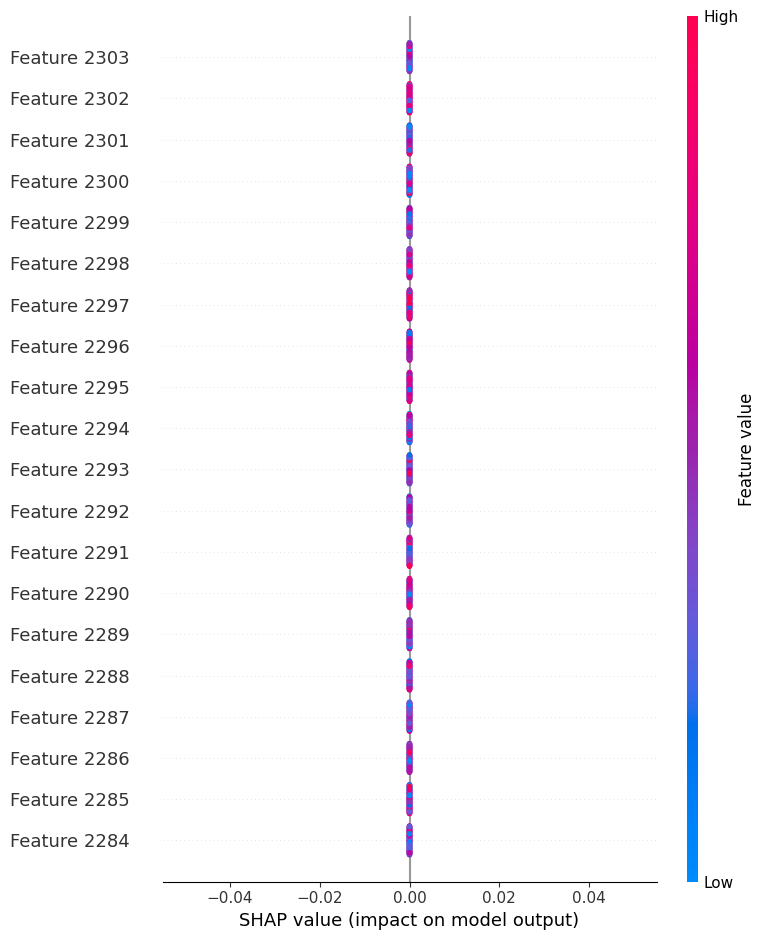

In [89]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)

In [90]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X,
    feature_names=[
        f"feat_{i}"
        for i in range(X.shape[1])
    ],
    class_names=[
        "IF",
        "PM",
        "SUS",
        "SC"
    ],
    mode="classification"
)

In [ ]:
print("hello")